# ЛАБОРАТОРНАЯ 10
**Тема:** Классификация спам-писем с использованием кастомной реализации Transformer Encoder.


**Постановка:** Необходимо отфильтровать нежелательную почту, самостоятельно реализовав ключевые компоненты внимания (MultiHeadAttention, PositionalEncoding). Обучить модель и интерпретировать выводы.

**Цель:** Освоить принципы архитектуры Transformer.

In [89]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/10 лаба/email.csv')


df.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Базовая информация о датасете

Проанализируем размер датасета, распределение классов "спам/не спам" и проверим данные на пропуски.

In [91]:
# базовая инфо
print(f'Количество строк: {df.shape[0]}')
print(f'Количество столбцов: {df.shape[1]}')

Количество строк: 5573
Количество столбцов: 2


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [93]:
print(df.isnull().sum())

Category    0
Message     0
dtype: int64


пропусков нет

In [94]:
print(df['Category'].value_counts())
print(f'\nПроцент спама: {df['Category'].value_counts(normalize=True)['spam']*100:.1f}%')
print(f'Процент легитимных писем: {df['Category'].value_counts(normalize=True)['ham']*100:.1f}%')

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

Процент спама: 13.4%
Процент легитимных писем: 86.6%


есть дисбаланс

категоризируем таргет

In [95]:
df['spam']=df['Category'].apply(lambda x: 1 if x=='spam' else 0)
df.head()

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [96]:
data = df.drop('Category', axis=1)
data.head()


,Message,spam
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [97]:
# базовые метрики текста
print('СРЕДНЯЯ ДЛИНА ТЕКСТА')
print(f'Спам: {df[df['spam']==1]['Message'].apply(len).mean():.1f} символов')
print(f'Не-спам: {df[df['spam']==0]['Message'].apply(len).mean():.1f} символов')

СРЕДНЯЯ ДЛИНА ТЕКСТА
Спам: 138.0 символов
Не-спам: 71.4 символов


In [98]:
print('СРЕДНЕЕ КОЛИЧЕСТВО СЛОВ')
print(f'Спам: {df[df['spam']==1]['Message'].apply(lambda x: len(x.split())).mean():.1f} слов')
print(f'Не-спам: {df[df['spam']==0]['Message'].apply(lambda x: len(x.split())).mean():.1f} слов')

СРЕДНЕЕ КОЛИЧЕСТВО СЛОВ
Спам: 23.8 слов
Не-спам: 14.3 слов


## Реализация компонент

С нуля реализуем ключевые компоненты Transformer: MultiHeadAttention, PositionalEncoding, TransformerEncoderLayer и TransformerEncoder.

In [99]:
# импорты
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import AutoTokenizer

In [100]:
# Компоненты

# 1. MultiHeadAttention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        q = self.W_q(q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        k = self.W_k(k).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        v = self.W_v(v).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        output = torch.matmul(attn, v)

        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(output)

# 2. PositionalEncoding (cosine)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# 3. TransformerEncoderLayer
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model)
        )

    def forward(self, x, mask=None):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))

        return x

# 4. TransformerEncoder
class TransformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, num_layers, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return x

# 5. TransformerClassifier
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=8, num_layers=3,
                 dim_feedforward=512, dropout=0.1, max_len=100):
        super().__init__()
        # Свой эмбеддер (базовый слой)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)

        # Ваши компоненты
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.encoder = TransformerEncoder(d_model, n_heads, num_layers, dim_feedforward, dropout)
        self.dropout = nn.Dropout(dropout)

        # Классификатор
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids):
        x = self.embedding(input_ids)       # Свой эмбеддер
        x = self.pos_encoding(x)            # PositionalEncoding
        x = self.dropout(x)
        x = self.encoder(x)                 # TransformerEncoder
        x = x.mean(dim=1)                   # Global average pooling
        return torch.sigmoid(self.classifier(x)).squeeze()

## Подготовка данных

Токенизируем текст с помощью готового токенизатора, разделим данные на train/test и создадим DataLoader для эффективной загрузки батчей.

In [101]:
# 1. готовый токенизатор
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 2. разделение данных
texts = df['Message'].tolist()
labels = df['spam'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Размер словаря: {tokenizer.vocab_size:,}")
print(f"Тренировочные данные: {len(X_train)}")
print(f"Тестовые данные: {len(X_test)}")

# 3. токенизация
MAX_LEN = 100

def tokenize_texts(texts_list):
    return tokenizer(
        texts_list,
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors='pt'
    )

train_encodings = tokenize_texts(X_train)
test_encodings = tokenize_texts(X_test)

Размер словаря: 30,522
Тренировочные данные: 4458
Тестовые данные: 1115


In [102]:
# датасет и даталоадер

class SpamDataset(Dataset):
    def __init__(self, encodings, labels):
        self.input_ids = encodings['input_ids']
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'label': self.labels[idx]
        }

# создаем датасеты
train_dataset = SpamDataset(train_encodings, y_train)
test_dataset = SpamDataset(test_encodings, y_test)

# даталоадеры
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Батчей в train_loader: {len(train_loader)}")
print(f"Батчей в test_loader: {len(test_loader)}")

Батчей в train_loader: 140
Батчей в test_loader: 35


## Обучение

### Модель

Соберем из реализованных компонентов полную модель TransformerClassifier для бинарной классификации текста.

In [103]:
# параметры модели
VOCAB_SIZE = tokenizer.vocab_size
D_MODEL = 128
N_HEADS = 4
NUM_LAYERS = 2

# создаем модель
model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    num_layers=NUM_LAYERS,
    dim_feedforward=256,
    dropout=0.2,
    max_len=MAX_LEN
)

# проверка компонентов
print(f"Параметров модели: {sum(p.numel() for p in model.parameters()):,}")

Параметров модели: 4,188,417


In [104]:
# оптимизатор
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

### Функция обучения + цикл

Определим функции для обучения и валидации модели, настроим оптимизатор и запустим цикл обучения на несколько эпох.

In [105]:
# функция обучения

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    preds, labels_list = [], []

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        batch_preds = (outputs > 0.5).float()

        preds.extend(batch_preds.cpu().detach().numpy())
        labels_list.extend(labels.cpu().numpy())

    accuracy = accuracy_score(labels_list, preds)
    f1 = f1_score(labels_list, preds)

    return total_loss / len(loader), accuracy, f1

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, labels_list = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            batch_preds = (outputs > 0.5).float()
            preds.extend(batch_preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    accuracy = accuracy_score(labels_list, preds)
    f1 = f1_score(labels_list, preds)

    return total_loss / len(loader), accuracy, f1, preds, labels_list

In [107]:
# цикл

EPOCHS = 5
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("НАЧАЛО ОБУЧЕНИЯ")
print("=" * 60)

for epoch in range(EPOCHS):
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, test_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Эпоха {epoch+1:2d}/{EPOCHS}")
    print(f"Train: Loss {train_loss:.4f} | Acc {train_acc:.4f} | F1 {train_f1:.4f}")
    print(f"Val:   Loss {val_loss:.4f} | Acc {val_acc:.4f} | F1 {val_f1:.4f}")
    print("-" * 60)

НАЧАЛО ОБУЧЕНИЯ
Эпоха  1/5
Train: Loss 0.2339 | Acc 0.9188 | F1 0.5810
Val:   Loss 0.1186 | Acc 0.9704 | F1 0.8773
------------------------------------------------------------
Эпоха  2/5
Train: Loss 0.0995 | Acc 0.9686 | F1 0.8774
Val:   Loss 0.0825 | Acc 0.9794 | F1 0.9176
------------------------------------------------------------
Эпоха  3/5
Train: Loss 0.0739 | Acc 0.9791 | F1 0.9191
Val:   Loss 0.0729 | Acc 0.9803 | F1 0.9214
------------------------------------------------------------
Эпоха  4/5
Train: Loss 0.0588 | Acc 0.9845 | F1 0.9408
Val:   Loss 0.0665 | Acc 0.9785 | F1 0.9161
------------------------------------------------------------
Эпоха  5/5
Train: Loss 0.0605 | Acc 0.9838 | F1 0.9385
Val:   Loss 0.0793 | Acc 0.9812 | F1 0.9247
------------------------------------------------------------


## Результаты

Проанализируем метрики качества модели на тестовых данных и визуализируем процесс обучения.

In [108]:
# оценки

val_loss, val_acc, val_f1, predictions, true_labels = evaluate(model, test_loader, criterion, device)

print("\n" + "="*60)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТЕ")
print("="*60)
print(f"Точность (Accuracy): {val_acc:.4f}")
print(f"F1-Score: {val_f1:.4f}")
print(f"Потери (Loss): {val_loss:.4f}")

print("\nОтчет классификации:")
print(classification_report(true_labels, predictions, target_names=['Ham', 'Spam'], digits=4))


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТЕ
Точность (Accuracy): 0.9812
F1-Score: 0.9247
Потери (Loss): 0.0793

Отчет классификации:
              precision    recall  f1-score   support

         Ham     0.9797    0.9990    0.9892       966
        Spam     0.9923    0.8658    0.9247       149

    accuracy                         0.9812      1115
   macro avg     0.9860    0.9324    0.9570      1115
weighted avg     0.9814    0.9812    0.9806      1115



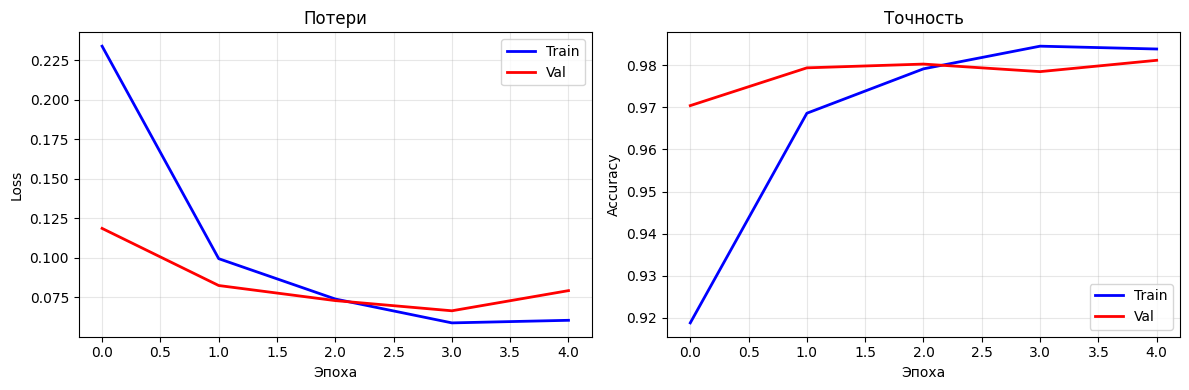

In [109]:
# визуализация

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График потерь
ax1.plot(history['train_loss'], 'b-', label='Train', linewidth=2)
ax1.plot(history['val_loss'], 'r-', label='Val', linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.set_title('Потери')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График точности
ax2.plot(history['train_acc'], 'b-', label='Train', linewidth=2)
ax2.plot(history['val_acc'], 'r-', label='Val', linewidth=2)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.set_title('Точность')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**ВЫВОД:** Модель показала высокую точность (98.1%), успешно детектируя спам с precision 99.2%. Реализация нашего трансформера подтвердила эффективность для задач классификации текстов на примере датасета с почтой. Для улучшения recall спама рекомендуется балансировка.